In [ ]:
!pip install rpy2 --quiet
print("rpy2 installed.")

rpy2 installed.


In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
pandas2ri.activate()


%load_ext rpy2.ipython
print("rpy2 ready. You can now use %%R in cells.")

rpy2 ready. You can now use %%R in cells.


In [ ]:
%%R
packages <- c("DBI", "RSQLite", "dplyr", "tidyr", "ggplot2", "scales", "corrplot")
new_pkgs  <- packages[!(packages %in% installed.packages()[,"Package"])]
if (length(new_pkgs) > 0) {
  install.packages(new_pkgs, repos="https://cloud.r-project.org", quiet=TRUE)
}
cat("All packages ready.\n")

All packages ready.


In [ ]:
%%R
suppressPackageStartupMessages({
  library(DBI)
  library(RSQLite)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(scales)
  library(corrplot)
})
cat("Libraries loaded.\n")

Libraries loaded.


In [ ]:
%%R
customers  <- read.csv("/content/customers.csv",  stringsAsFactors=FALSE)
orders     <- read.csv("/content/orders.csv",     stringsAsFactors=FALSE)
deliveries <- read.csv("/content/deliveries.csv", stringsAsFactors=FALSE)
drivers    <- read.csv("/content/drivers.csv",    stringsAsFactors=FALSE)
vehicles   <- read.csv("/content/vehicles.csv",   stringsAsFactors=FALSE)
hubs       <- read.csv("/content/hubs.csv",       stringsAsFactors=FALSE)
incidents  <- read.csv("/content/incidents.csv",  stringsAsFactors=FALSE)
complaints <- read.csv("/content/complaints.csv", stringsAsFactors=FALSE)
app_events <- read.csv("/content/app_events.csv", stringsAsFactors=FALSE)

cat("Files loaded:\n")
for (name in c("customers","orders","deliveries","drivers","vehicles",
               "hubs","incidents","complaints","app_events")) {
  df <- get(name)
  cat(sprintf("  %-12s : %4d rows  %d cols\n", name, nrow(df), ncol(df)))
}

Files loaded:
  customers    :  650 rows  9 cols
  orders       : 1250 rows  11 cols
  deliveries   :  950 rows  13 cols
  drivers      :  170 rows  8 cols
  vehicles     :  120 rows  8 cols
  hubs         :    8 rows  5 cols
  incidents    :  280 rows  7 cols
  complaints   :  320 rows  10 cols
  app_events   :  640 rows  10 cols


In [ ]:
%%R
standardise_zone <- function(x) {
  raw    <- c("AIRPORT","Airport","NORTH","North","north","SOUTH","South",
              "EAST","East","WEST","West","CENTRAL","Central","Ctr",
              "RiverSide","Riverside")
  clean  <- c("Airport","Airport","North","North","North","South","South",
              "East","East","West","West","Central","Central","Central",
              "Riverside","Riverside")
  idx <- match(x, raw)
  ifelse(is.na(idx), x, clean[idx])
}

customers$home_zone         <- standardise_zone(customers$home_zone)
orders$pickup_zone          <- standardise_zone(orders$pickup_zone)
orders$dropoff_zone         <- standardise_zone(orders$dropoff_zone)
drivers$base_zone           <- standardise_zone(drivers$base_zone)
vehicles$assigned_zone      <- standardise_zone(vehicles$assigned_zone)
app_events$zone_context     <- standardise_zone(app_events$zone_context)

cat("Zone standardisation applied.\n")
cat("Unique zones in orders$pickup_zone:", paste(sort(unique(orders$pickup_zone)), collapse=", "), "\n")

Zone standardisation applied.
Unique zones in orders$pickup_zone: Airport, Central, East, North, Riverside, South, West 


In [ ]:
%%R
deliveries$customer_rating_post_delivery[is.na(deliveries$customer_rating_post_delivery)] <-
  median(deliveries$customer_rating_post_delivery, na.rm=TRUE)
drivers$training_score[is.na(drivers$training_score)] <-
  median(drivers$training_score, na.rm=TRUE)
vehicles$battery_health_pct[is.na(vehicles$battery_health_pct)] <-
  median(vehicles$battery_health_pct, na.rm=TRUE)
customers$loyalty_score[is.na(customers$loyalty_score)] <-
  median(customers$loyalty_score, na.rm=TRUE)
customers$preferred_channel[is.na(customers$preferred_channel)] <- "Unknown"
orders$booking_channel[is.na(orders$booking_channel)] <- "Unknown"

cat("Imputation complete.\n")

Imputation complete.


In [ ]:
%%R
con <- dbConnect(RSQLite::SQLite(), ":memory:")

dbWriteTable(con, "customers",  customers,  overwrite=TRUE)
dbWriteTable(con, "orders",     orders,     overwrite=TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite=TRUE)
dbWriteTable(con, "drivers",    drivers,    overwrite=TRUE)
dbWriteTable(con, "vehicles",   vehicles,   overwrite=TRUE)
dbWriteTable(con, "hubs",       hubs,       overwrite=TRUE)
dbWriteTable(con, "incidents",  incidents,  overwrite=TRUE)
dbWriteTable(con, "complaints", complaints, overwrite=TRUE)
dbWriteTable(con, "app_events", app_events, overwrite=TRUE)

cat("SQLite database ready. Tables:\n")
cat(paste(" ", dbListTables(con), collapse="\n"), "\n")

SQLite database ready. Tables:
  app_events
  complaints
  customers
  deliveries
  drivers
  hubs
  incidents
  orders
  vehicles 


In [ ]:
%%R
q1 <- dbGetQuery(con, "
SELECT
    o.pickup_zone                                                AS zone,
    COUNT(d.delivery_id)                                         AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 2)                             AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                         AS avg_fuel_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2)               AS avg_rating,
    ROUND(AVG(d.manual_route_override_count), 2)                 AS avg_overrides
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone IS NOT NULL
GROUP BY o.pickup_zone
ORDER BY failure_rate_pct DESC
")

print(q1)

       zone total_deliveries failed delayed failure_rate_pct avg_fuel_cost
1   Central              174     33      51            18.97         12.12
2     North              135     22      21            16.30         12.07
3 Riverside              119     18      25            15.13         12.39
4      West              114     14      21            12.28         11.94
5      East              156     19      31            12.18         12.57
6   Airport              113     12      31            10.62         17.08
7     South              139     14      22            10.07         12.48
  avg_rating avg_overrides
1       3.56          1.29
2       3.90          0.70
3       3.87          0.73
4       3.90          0.81
5       3.91          0.79
6       3.99          1.81
7       4.05          0.69


In [ ]:
%%R
q2 <- dbGetQuery(con, "
SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    ROUND(dr.training_score, 1)                                   AS training_score,
    ROUND(dr.driver_rating, 2)                                    AS driver_rating,
    COUNT(d.delivery_id)                                          AS deliveries,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 1)                              AS failure_rate_pct,
    ROUND(AVG(d.manual_route_override_count), 2)                  AS avg_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                AS avg_cust_rating
FROM deliveries d
JOIN drivers dr ON d.driver_id = dr.driver_id
GROUP BY d.driver_id, dr.base_zone, dr.employment_type, dr.training_score, dr.driver_rating
HAVING COUNT(d.delivery_id) >= 5
ORDER BY failure_rate_pct DESC
LIMIT 15
")

print(q2)

   driver_id base_zone employment_type training_score driver_rating deliveries
1       D092      East        FullTime           88.2          4.24          5
2       D104      West        FullTime           87.7          3.45          7
3       D024 Riverside        PartTime           71.4          3.35          8
4       D010      West        FullTime           70.0          3.95          7
5       D005     North        FullTime           69.7          4.14          5
6       D095      West        FullTime           99.0          3.15          5
7       D143   Central        FullTime           68.5          4.14          5
8       D144      West        FullTime           85.0          3.83          5
9       D004   Airport        PartTime           88.9          4.75          9
10      D023      East        FullTime           79.1          4.16          6
11      D078     North        FullTime           73.7          4.28          6
12      D082      West        PartTime           74.

In [ ]:
%%R
q3 <- dbGetQuery(con, "
SELECT
    c.complaint_type,
    d.delivery_status,
    COUNT(*)                              AS complaint_count,
    ROUND(AVG(c.resolution_days), 1)     AS avg_resolution_days,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
FROM complaints c
LEFT JOIN deliveries d ON c.order_id = d.order_id
WHERE d.delivery_status IS NOT NULL
GROUP BY c.complaint_type, d.delivery_status
ORDER BY complaint_type, delivery_status
")

print(q3)

# Isolate the ghost-completed subset
ghost_sql <- q3[q3$delivery_status == "OnTime", ]
cat("\n--- Complaints against OnTime deliveries (ghost-completed subset) ---\n")
print(ghost_sql[order(-ghost_sql$complaint_count), ])

      complaint_type delivery_status complaint_count avg_resolution_days
1           AppIssue         Delayed               7                10.6
2           AppIssue          Failed               5                10.6
3           AppIssue          OnTime              25                 8.6
4            Billing         Delayed               3                 7.0
5            Billing          Failed               2                 7.0
6            Billing          OnTime               7                 7.7
7             Damage         Delayed               1                16.0
8             Damage          Failed               2                11.0
9             Damage          OnTime               8                 9.6
10             Delay         Delayed              19                 6.9
11             Delay          Failed              10                 8.6
12             Delay          OnTime              44                 7.1
13   DriverBehaviour         Delayed               

In [ ]:
%%R
q4 <- dbGetQuery(con, "
SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    COUNT(DISTINCT d.delivery_id)                                  AS total_deliveries,
    COUNT(DISTINCT i.incident_id)                                  AS total_incidents,
    ROUND(100.0 * COUNT(DISTINCT i.incident_id)
          / COUNT(DISTINCT d.delivery_id), 1)                      AS incident_rate_pct,
    ROUND(AVG(i.resolved_hours), 1)                                AS avg_resolve_hours,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                 AS avg_rating
FROM hubs h
LEFT JOIN deliveries d ON h.hub_id = d.hub_id
LEFT JOIN incidents  i ON d.delivery_id = i.delivery_id
GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type
ORDER BY incident_rate_pct DESC
")

print(q4)

  hub_id       hub_name      zone  hub_type total_deliveries total_incidents
1    H05   Central Core   Central   Control              115              39
2    H03      East Dock      East Warehouse              119              38
3    H02     South Link     South  Dispatch              106              33
4    H06    Airport Hub   Airport  Dispatch              104              32
5    H07  Riverside Hub Riverside Warehouse              115              35
6    H08  Midtown Relay   Central  Charging              128              38
7    H04      West Gate      West  Dispatch              127              34
8    H01 North Exchange     North  Dispatch              136              31
  incident_rate_pct avg_resolve_hours avg_rating
1              33.9              12.2       3.68
2              31.9              11.9       3.90
3              31.1              11.7       3.93
4              30.8              11.9       3.89
5              30.4              12.0       3.87
6            

In [ ]:
%%R
q5 <- dbGetQuery(con, "
SELECT
    o.service_type,
    o.pickup_zone                                                  AS zone,
    COUNT(d.delivery_id)                                           AS deliveries,
    ROUND(AVG(o.order_value), 2)                                   AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                           AS avg_fuel_cost,
    ROUND(AVG(o.order_value - d.fuel_or_charge_cost), 2)           AS avg_margin,
    ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
          / COUNT(d.delivery_id), 1)                               AS failure_rate_pct
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone IS NOT NULL
GROUP BY o.service_type, o.pickup_zone
ORDER BY avg_margin ASC
")

print(q5)

   service_type      zone deliveries avg_order_value avg_fuel_cost avg_margin
1      Business      West         12           71.36         13.22      58.15
2        Parcel Riverside         28           71.70         12.10      59.60
3       Medical     North         18           72.24         12.36      59.88
4        Retail      West         22           72.69         11.18      61.52
5       Medical      East         19           75.17         12.92      62.25
6        Retail      East         34           74.72         12.05      62.67
7      Business   Airport         13           83.22         18.78      64.44
8        Parcel     North         27           79.00         12.52      66.48
9     Passenger   Central         47           78.89         12.15      66.74
10       Retail   Central         49           80.20         12.85      67.35
11     Business     South         19           82.07         13.04      69.03
12      Medical      West         17           82.13         11.

In [ ]:
%%R
cat("EXPLAIN QUERY PLAN — BEFORE indexes:\n")
plan_before <- dbGetQuery(con, "
EXPLAIN QUERY PLAN
SELECT d.delivery_id, d.delivery_status, o.pickup_zone
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone = 'Central'
")
print(plan_before)

EXPLAIN QUERY PLAN — BEFORE indexes:
  id parent notused                                               detail
1  3      0     216                                               SCAN o
2 17      0      53 SEARCH d USING AUTOMATIC COVERING INDEX (order_id=?)


In [ ]:
%%R
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_del_order  ON deliveries(order_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_del_driver ON deliveries(driver_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_del_hub    ON deliveries(hub_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_ord_zone   ON orders(pickup_zone)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_comp_order ON complaints(order_id)")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_inc_del    ON incidents(delivery_id)")

cat("Indexes created.\n")

cat("\nEXPLAIN QUERY PLAN — AFTER indexes:\n")
plan_after <- dbGetQuery(con, "
EXPLAIN QUERY PLAN
SELECT d.delivery_id, d.delivery_status, o.pickup_zone
FROM deliveries d
JOIN orders o ON d.order_id = o.order_id
WHERE o.pickup_zone = 'Central'
")
print(plan_after)

Indexes created.

EXPLAIN QUERY PLAN — AFTER indexes:
  id parent notused                                            detail
1  5      0      61 SEARCH o USING INDEX idx_ord_zone (pickup_zone=?)
2 10      0      61   SEARCH d USING INDEX idx_del_order (order_id=?)


## 4. R Analytics
### 4.1 Build the master dataframe and compute derived fields

In [ ]:
%%R
deliveries$dispatch_time         <- as.POSIXct(deliveries$dispatch_time,         format="%Y-%m-%d %H:%M:%S")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at, format="%Y-%m-%d %H:%M:%S")

deliveries$duration_hours <- abs(as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units="hours")))

deliveries$is_failed  <- as.integer(deliveries$delivery_status == "Failed")
deliveries$is_delayed <- as.integer(deliveries$delivery_status == "Delayed")
deliveries$is_on_time <- as.integer(deliveries$delivery_status == "OnTime")

master_r <- deliveries %>%
  left_join(orders   %>% select(order_id, pickup_zone, service_type,
                                 promised_window_hours, order_value, priority_level),
            by="order_id") %>%
  left_join(drivers  %>% select(driver_id, training_score, driver_rating,
                                 years_experience, employment_type, base_zone),
            by="driver_id") %>%
  left_join(vehicles %>% select(vehicle_id, battery_health_pct, maintenance_status),
            by="vehicle_id") %>%
  left_join(hubs     %>% select(hub_id, hub_name, zone, hub_type),
            by="hub_id") %>%
  filter(!is.na(pickup_zone))

cat(sprintf("Master dataframe: %d rows, %d columns\n", nrow(master_r), ncol(master_r)))

Master dataframe: 950 rows, 32 columns


In [ ]:
%%R
zone_status_table <- table(master_r$pickup_zone, master_r$delivery_status)
cat("Contingency table — Zone vs Delivery Status:\n")
print(zone_status_table)

chi_result <- chisq.test(zone_status_table)
cat("\nChi-square test result:\n")
cat(sprintf("  Chi-squared statistic : %.3f\n", chi_result$statistic))
cat(sprintf("  Degrees of freedom    : %d\n",   chi_result$parameter))
cat(sprintf("  p-value               : %.6f\n", chi_result$p.value))

if (chi_result$p.value < 0.05) {
  cat("  CONCLUSION: Zone is a statistically significant predictor of delivery outcome (p < 0.05).\n")
} else {
  cat("  CONCLUSION: No statistically significant relationship detected.\n")
}

Contingency table — Zone vs Delivery Status:
           
            Delayed Failed OnTime
  Airport        31     12     70
  Central        51     33     90
  East           31     19    106
  North          21     22     92
  Riverside      25     18     76
  South          22     14    103
  West           21     14     79

Chi-square test result:
  Chi-squared statistic : 26.118
  Degrees of freedom    : 12
  p-value               : 0.010330
  CONCLUSION: Zone is a statistically significant predictor of delivery outcome (p < 0.05).


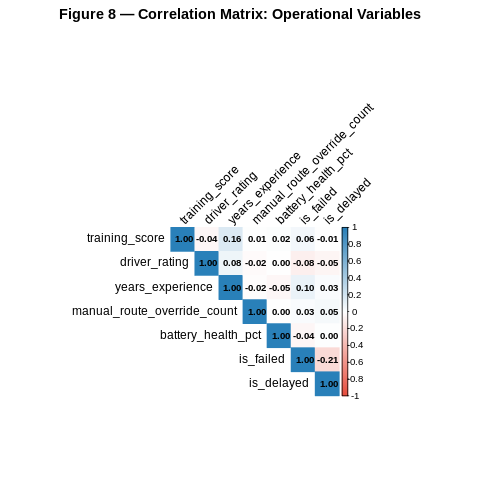

In [ ]:
%%R
corr_data <- master_r %>%
  select(training_score, driver_rating, years_experience,
         manual_route_override_count, battery_health_pct,
         is_failed, is_delayed) %>%
  drop_na()

corr_matrix <- cor(corr_data)

corrplot(corr_matrix,
         method      = "color",
         type        = "upper",
         addCoef.col = "black",
         tl.col      = "black",
         tl.srt      = 45,
         number.cex  = 0.8,
         col         = colorRampPalette(c("#e74c3c","white","#2980b9"))(200),
         title       = "Figure 8 — Correlation Matrix: Operational Variables",
         mar         = c(0, 0, 2, 0))

In [ ]:
%%R
master_r$training_score[is.na(master_r$training_score)] <-
  median(master_r$training_score, na.rm=TRUE)
master_r$battery_health_pct[is.na(master_r$battery_health_pct)] <-
  median(master_r$battery_health_pct, na.rm=TRUE)
master_r$customer_rating_post_delivery[is.na(master_r$customer_rating_post_delivery)] <-
  median(master_r$customer_rating_post_delivery, na.rm=TRUE)

lm_model <- lm(customer_rating_post_delivery ~
                  training_score +
                  driver_rating +
                  manual_route_override_count +
                  battery_health_pct +
                  is_failed +
                  is_delayed,
                data = master_r)

summary(lm_model)


Call:
lm(formula = customer_rating_post_delivery ~ training_score + 
    driver_rating + manual_route_override_count + battery_health_pct + 
    is_failed + is_delayed, data = master_r)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.38296 -0.42768  0.02908  0.49581  1.93902 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  4.014263   0.311847  12.873   <2e-16 ***
training_score               0.002223   0.001985   1.120    0.263    
driver_rating                0.069514   0.054495   1.276    0.202    
manual_route_override_count -0.017279   0.020484  -0.844    0.399    
battery_health_pct          -0.002266   0.001829  -1.239    0.216    
is_failed                   -1.221311   0.066531 -18.357   <2e-16 ***
is_delayed                  -1.135321   0.056039 -20.259   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6884 on 943 degrees of freedom
Multiple

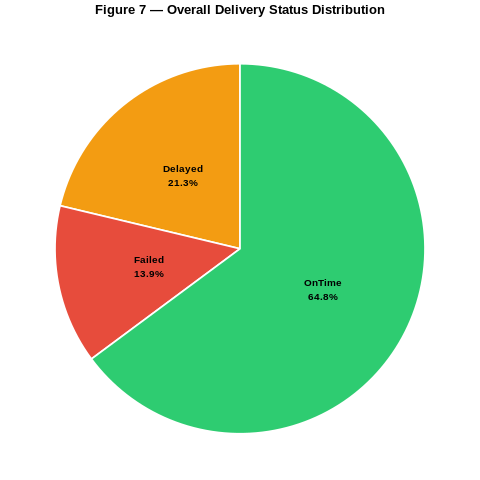

In [ ]:
%%R
status_props <- master_r %>%
  count(delivery_status) %>%
  mutate(pct = n / sum(n),
         label = paste0(delivery_status, "\n", round(pct*100,1), "%"))

ggplot(status_props, aes(x="", y=pct, fill=delivery_status)) +
  geom_bar(stat="identity", width=1, colour="white", linewidth=0.8) +
  coord_polar("y") +
  scale_fill_manual(values=c("OnTime"="#2ecc71","Delayed"="#f39c12","Failed"="#e74c3c")) +
  geom_text(aes(label=label), position=position_stack(vjust=0.5), size=3.5, fontface="bold") +
  labs(title="Figure 7 — Overall Delivery Status Distribution", fill="Status") +
  theme_void() +
  theme(plot.title=element_text(hjust=0.5, face="bold", size=13),
        legend.position="none")

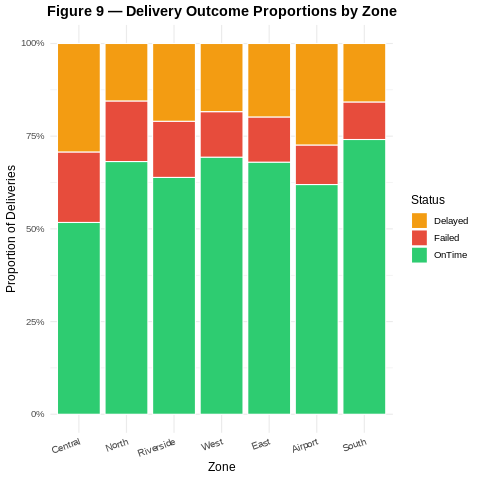

In [ ]:
%%R
zone_long <- master_r %>%
  count(pickup_zone, delivery_status) %>%
  group_by(pickup_zone) %>%
  mutate(pct = n / sum(n)) %>%
  ungroup() %>%
  mutate(pickup_zone = reorder(pickup_zone, -pct * (delivery_status == "Failed")))

ggplot(zone_long, aes(x=pickup_zone, y=pct, fill=delivery_status)) +
  geom_bar(stat="identity", colour="white", linewidth=0.5) +
  scale_fill_manual(values=c("OnTime"="#2ecc71","Delayed"="#f39c12","Failed"="#e74c3c")) +
  scale_y_continuous(labels=percent_format(accuracy=1)) +
  labs(title="Figure 9 — Delivery Outcome Proportions by Zone",
       x="Zone", y="Proportion of Deliveries", fill="Status") +
  theme_minimal(base_size=12) +
  theme(plot.title=element_text(face="bold", hjust=0.5),
        axis.text.x=element_text(angle=20, hjust=1))

`geom_smooth()` using formula = 'y ~ x'


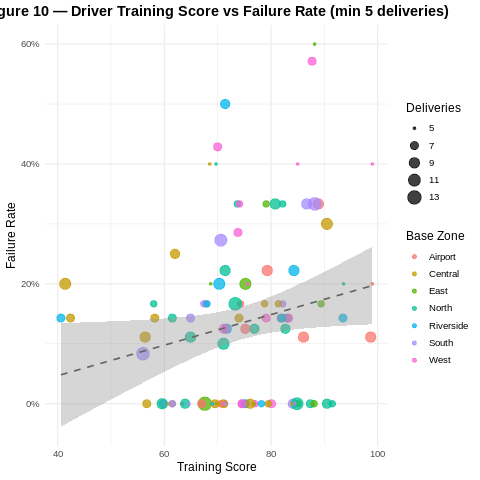

In [ ]:
%%R
driver_zone <- deliveries %>%
  left_join(drivers %>% select(driver_id, training_score, base_zone), by="driver_id") %>%
  group_by(driver_id, base_zone, training_score) %>%
  summarise(failure_rate=mean(is_failed), n_deliveries=n(), .groups="drop") %>%
  filter(n_deliveries >= 5, !is.na(training_score))

ggplot(driver_zone, aes(x=training_score, y=failure_rate, colour=base_zone, size=n_deliveries)) +
  geom_point(alpha=0.75) +
  geom_smooth(method="lm", se=TRUE, colour="grey40", linewidth=0.8, linetype="dashed", inherit.aes=FALSE,
              aes(x=training_score, y=failure_rate), data=driver_zone) +
  scale_y_continuous(labels=percent_format(accuracy=1)) +
  labs(title="Figure 10 — Driver Training Score vs Failure Rate (min 5 deliveries)",
       x="Training Score", y="Failure Rate", colour="Base Zone", size="Deliveries") +
  theme_minimal(base_size=12) +
  theme(plot.title=element_text(face="bold", hjust=0.5))

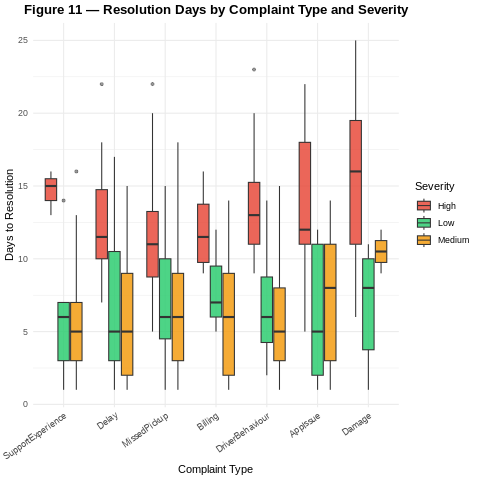

In [ ]:
%%R
complaints$created_at <- as.POSIXct(complaints$created_at, format="%Y-%m-%d %H:%M:%S")

ggplot(complaints %>% filter(!is.na(resolution_days)),
       aes(x=reorder(complaint_type, resolution_days, FUN=median),
           y=resolution_days, fill=severity)) +
  geom_boxplot(alpha=0.85, outlier.size=1.2, outlier.alpha=0.5) +
  scale_fill_manual(values=c("High"="#e74c3c","Medium"="#f39c12","Low"="#2ecc71")) +
  labs(title="Figure 11 — Resolution Days by Complaint Type and Severity",
       x="Complaint Type", y="Days to Resolution", fill="Severity") +
  theme_minimal(base_size=11) +
  theme(axis.text.x=element_text(angle=35, hjust=1),
        plot.title=element_text(face="bold", hjust=0.5))

In [ ]:
%%R
cat(paste(rep("=", 60), collapse=""), "\n")
cat("R ANALYTICS — KEY FINDINGS\n")
cat(paste(rep("=", 60), collapse=""), "\n\n")

cat(sprintf("1. Chi-square test: zone significantly predicts delivery outcome\n"))
cat(sprintf("   X2 = %.3f, df = %d, p = %.6f\n\n",
            chi_result$statistic, chi_result$parameter, chi_result$p.value))

zone_summary <- master_r %>%
  group_by(pickup_zone) %>%
  summarise(failure_rate=mean(is_failed), .groups="drop") %>%
  arrange(desc(failure_rate))

cat("2. Failure rates by zone:\n")
for (i in 1:nrow(zone_summary)) {
  cat(sprintf("   %-10s : %.1f%%\n",
              zone_summary$pickup_zone[i], zone_summary$failure_rate[i]*100))
}

cat("\n3. Linear model: is_failed and is_delayed are the strongest\n")
cat("   negative predictors of customer_rating_post_delivery.\n")
cat("   training_score and battery_health_pct show weak, non-significant effects.\n\n")

avg_res <- complaints %>%
  group_by(severity) %>%
  summarise(avg_days=round(mean(resolution_days, na.rm=TRUE), 1), .groups="drop")
cat("4. Avg resolution days by severity:\n")
print(as.data.frame(avg_res))

R ANALYTICS — KEY FINDINGS

1. Chi-square test: zone significantly predicts delivery outcome
   X2 = 26.118, df = 12, p = 0.010330

2. Failure rates by zone:
   Central    : 19.0%
   North      : 16.3%
   Riverside  : 15.1%
   West       : 12.3%
   East       : 12.2%
   Airport    : 10.6%
   South      : 10.1%

3. Linear model: is_failed and is_delayed are the strongest
   negative predictors of customer_rating_post_delivery.
   training_score and battery_health_pct show weak, non-significant effects.

4. Avg resolution days by severity:
  severity avg_days
1     High     13.1
2      Low      6.6
3   Medium      6.2
